In [1]:

import numpy as np 
import pandas as pd
import math

from keras.models import Model
from keras.layers import Input, LSTM, Dense,TimeDistributed, Bidirectional

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from keras.utils import to_categorical,Sequence
from keras.optimizers import Adam
from keras.callbacks import TensorBoard,ModelCheckpoint

from keras import backend  as K
import tensorflow as tf



In [12]:
df = pd.read_csv(r"H:\\THESIS\\DATASET\\2022-08-03-ss.cleaned.csv").sort_values(by=['pdb_id','chain_code'])
print('number of rows (sequences): {}'.format(df.shape[0]))
print('number of unique proteins: {}'.format(len(df.pdb_id.unique())))
df.head()

number of rows (sequences): 477153
number of unique proteins: 164619


,pdb_id,chain_code,seq,sst8,sst3,len,has_nonstd_aa
146703,101M,A,MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDR...,CCCCHHHHHHHHHHHHHHGGGHHHHHHHHHHHHHHHCGGGGGGCTT...,CCCCHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHCHHHHHHCCC...,154,False
162296,102L,A,MNIFEMLRIDEGLRLKIYKDTEGYYTIGIGHLLTKSPSLNAAAKSE...,CCHHHHHHHHHCCEEEEEECTTSCEEEETTEEEESSSCTTTHHHHH...,CCHHHHHHHHHCCEEEEEECCCCCEEEECCEEEECCCCCCCHHHHH...,165,False
146704,102M,A,MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDR...,CCCCHHHHHHHHHHHHHHGGGHHHHHHHHHHHHHHHCGGGGGGCTT...,CCCCHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHCHHHHHHCCC...,154,False
164681,103L,A,MNIFEMLRIDEGLRLKIYKDTEGYYTIGIGHLLTKSPSLNSLDAAK...,CCHHHHHHHHHCCEEEEEECTTSCEEEETTEECCCCCCCCCHHHHH...,CCHHHHHHHHHCCEEEEEECCCCCEEEECCEECCCCCCCCCHHHHH...,167,False
146705,103M,A,MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDR...,CCCCHHHHHHHHHHHHHHGGGHHHHHHHHHHHHHHHCGGGGGGCTT...,CCCCHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHHCHHHHHHCCC...,154,False


<Axes: xlabel='number of chains'>

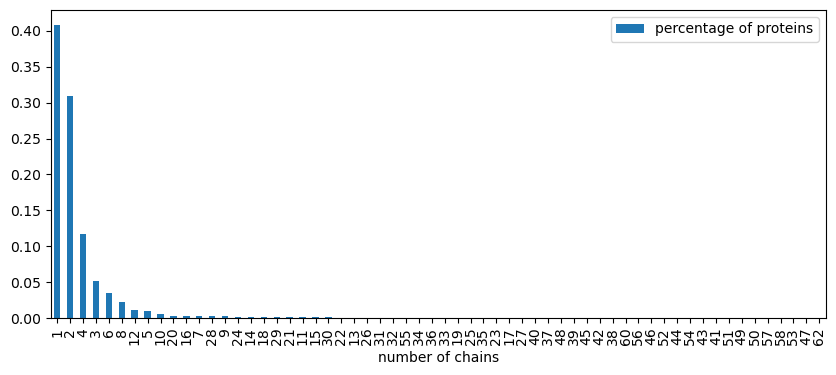

In [3]:
gb = df.groupby(['pdb_id'],as_index=False)['chain_code'].count().sort_values(by='chain_code',ascending=False)
gb.rename(columns={'chain_code':'number of chains'},inplace=True)
gb2 = gb.groupby('number of chains',as_index=False)['pdb_id'].count().sort_values(by='pdb_id',ascending=False)

gb3 = gb2.rename(columns={'pdb_id':'proteins count'})
gb3['percentage of proteins'] = gb3['proteins count']/len(df.pdb_id.unique())
gb3.plot.bar(x='number of chains',y='percentage of proteins',figsize=(10,4))

In [4]:
a = df.loc[df.pdb_id=='1A30'].sort_values(by='chain_code')
a

,pdb_id,chain_code,seq,sst8,sst3,len,has_nonstd_aa
66965,1A30,A,PQITLWKRPLVTIKIGGQLKEALLDTGADDTVIEEMSLPGRWKPKM...,CEECSSSCCEEEEEETTEEEEEEECTTBSSCEEESCCCCSCCEEEE...,CEECCCCCCEEEEEECCEEEEEEECCCECCCEEECCCCCCCCEEEE...,99,False
66966,1A30,B,PQITLWKRPLVTIKIGGQLKEALLDTGADDTVIEEMSLPGRWKPKM...,CEECSSSCCEEEEEETTEEEEEEECTTCSSCEECSCCCSSCCEEEE...,CEECCCCCCEEEEEECCEEEEEEECCCCCCCEECCCCCCCCCEEEE...,99,False
0,1A30,C,EDL,CBC,CEC,3,False


In [5]:
print('Chain {} Sequence:\n{}'.format('A',a.loc[a.chain_code=='A','seq'].values[0]))
print('Chain {} Sequence:\n{}'.format('B',a.loc[a.chain_code=='B','seq'].values[0]))

Chain A Sequence:
PQITLWKRPLVTIKIGGQLKEALLDTGADDTVIEEMSLPGRWKPKMIGGIGGFIKVRQYDQIIIEICGHKAIGTVLVGPTPVNIIGRNLLTQIGCTLNF
Chain B Sequence:
PQITLWKRPLVTIKIGGQLKEALLDTGADDTVIEEMSLPGRWKPKMIGGIGGFIKVRQYDQIIIEICGHKAIGTVLVGPTPVNIIGRNLLTQIGCTLNF


In [6]:
print('Chain {} Q8:\n{}'.format('A',a.loc[a.chain_code=='A','sst8'].values[0]))
print('Chain {} Q8:\n{}'.format('B',a.loc[a.chain_code=='B','sst8'].values[0]))

Chain A Q8:
CEECSSSCCEEEEEETTEEEEEEECTTBSSCEEESCCCCSCCEEEEEEETTEEEEEEEEEEEEEEETTEEEEEEEEEECCSSCEECHHHHTTTTCEEEC
Chain B Q8:
CEECSSSCCEEEEEETTEEEEEEECTTCSSCEECSCCCSSCCEEEEEECSSCEEEEEEEEEEEEEETTEEEEEEEEESCCSSCEECHHHHTTTTCEEEC


In [7]:
print('Chain {} Q3:\n{}'.format('A',a.loc[a.chain_code=='A','sst3'].values[0]))
print('Chain {} Q3:\n{}'.format('B',a.loc[a.chain_code=='B','sst3'].values[0]))

Chain A Q3:
CEECCCCCCEEEEEECCEEEEEEECCCECCCEEECCCCCCCCEEEEEEECCEEEEEEEEEEEEEEECCEEEEEEEEEECCCCCEECHHHHCCCCCEEEC
Chain B Q3:
CEECCCCCCEEEEEECCEEEEEEECCCCCCCEECCCCCCCCCEEEEEECCCCEEEEEEEEEEEEEECCEEEEEEEEECCCCCCEECHHHHCCCCCEEEC


In [8]:
# most popular sequences
gb = df.groupby('seq',as_index=False)['chain_code'].count().sort_values(by='chain_code',ascending=False)
gb.rename(columns={'chain_code':'sequence occurence'},inplace=True)
gb[['sequence occurence']].describe()


,sequence occurence
count,112700.000000
mean,4.233833
std,14.644731
min,1.000000
25%,1.000000
50%,2.000000
75%,4.000000
max,2580.000000


## B. Predicting the secondary structure of a chain

#### Data Preprocessing Steps


1.    Subset only **unique pairs** of sequences and Q3 secondary structures (sst3) to avoid redundancy when evaluating the model (remember that a given sequence can have multiple sst3 within or across proteins.
2.   Split the data into training/validation/test sets.

3.   Convert the sequences to numerical format before we can feed them to a model.

I have compute constraints,  I will limit the datasets to sequences no longer than 128.

In [13]:


# subset unique pairs seq/sst3 and exclude 
max_len = 128
df = df.loc[(df.len <= max_len)]

print('There are {} seq with length 128 or less.'.format(df.shape[0]))
df = df.loc[:,['seq','sst3']].drop_duplicates()
print('There are {} unique seq / sst3 pairs.'.format(df.shape[0]))

There are 110457 seq with length 128 or less.
There are 68065 unique seq / sst3 pairs.


fold

In [14]:
## split data into train/val/test
RS = 15141312
np.random.seed(RS)

val_size=.10
test_size=.10

df['split'] = np.random.rand(len(df))

df_val = df.loc[df.split < val_size]
df_test = df.loc[(df.split < val_size + test_size) & (df.split >= val_size)]
df_train = df.loc[df.split >= val_size + test_size]

print(df_train.shape,df_test.shape,df_val.shape)

(54455, 3) (6832, 3) (6778, 3)


In [15]:
# preprocesing input sequence and sst8
input_tk = Tokenizer(char_level=True,lower=False)
input_tk.fit_on_texts(df.seq)

target_tk = Tokenizer(char_level=True,lower=False)
target_tk.fit_on_texts(df.sst3)

# char to index
input_char_index = input_tk.word_index
target_char_index = target_tk.word_index

# index to char
input_index_char = dict((i, char) for char, i in input_char_index.items())
target_index_char = dict((i, char) for char, i in target_char_index.items())

# number of tokens (including padding)
num_input_tokens = 1 + len(input_char_index.items())
num_target_tokens = 1 + len(target_char_index.items())

# vectorizing
def trans_seq_in(iseq):
    maxlen = max([len(txt) for txt in iseq])
    input_seq = input_tk.texts_to_sequences(iseq)
    input_seq = pad_sequences(input_seq,maxlen=maxlen,padding='post',value=0)
    return to_categorical(input_seq,num_classes=num_input_tokens)

def trans_seq_out(iseq):
    maxlen = max([len(txt) for txt in iseq])
    target_seq = target_tk.texts_to_sequences(iseq)
    target_seq = pad_sequences(target_seq,maxlen=maxlen,padding='post',value=0)
    return to_categorical(target_seq,num_classes=num_target_tokens)

In [17]:
# generate training and testing data,labels pairs
def ProteinV(data):
    x = trans_seq_in(data.seq)
    y = trans_seq_out(data.sst3)
    return x, y
   
x_train,y_train = ProteinV(df_train)
x_val,y_val = ProteinV(df_val)
x_test,y_test = ProteinV(df_test)

In [18]:
x_train.shape,y_train.shape,x_val.shape,y_val.shape,x_test.shape,y_test.shape

((54455, 128, 22),
 (54455, 128, 4),
 (6778, 128, 22),
 (6778, 128, 4),
 (6832, 128, 22),
 (6832, 128, 4))

In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [20]:
# Check if GPU is available
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPUs Available: {len(gpus)}")
    for gpu in gpus:
        print(f"GPU: {gpu}")
else:
    print("No GPU available, using CPU.")

No GPU available, using CPU.


# v_RNN model

In [21]:


from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, RNN, Dense, TimeDistributed
from tensorflow.keras import layers

# Set up model.
x_in = Input(shape=(None, num_input_tokens))
x = Bidirectional(RNN(layers.SimpleRNNCell(128), return_sequences=True))(x_in)
x = TimeDistributed(Dense(100, activation='relu'))(x)
x_out = TimeDistributed(Dense(num_target_tokens, activation='softmax'))(x)

mdl_2 = Model(x_in, x_out)
mdl_2.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, None, 22)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, None, 256)      │        38,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, None, 100)      │        25,700 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, None, 4)        │           404 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,760 (252.97 KB)

 Trainable params: 64,760 (252.97 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
import tensorflow as tf
from tensorflow.keras.layers import RNN, SimpleRNNCell

def q3_acc(y_true, y_pred):
    # Convert y_pred from one-hot encoding to class indices
    y_pred_labels = tf.argmax(y_pred, axis=-1)
    # Ensure y_true is also in class indices
    y_true_labels = tf.cast(tf.argmax(y_true, axis=-1), tf.int32) if y_true.shape.ndims == 3 else tf.cast(y_true, tf.int32)
    # Mask to ignore padding tokens (assuming padding tokens are 0)
    mask = tf.greater(y_true_labels, 0)
    # Ensure both tensors are int32 for comparison
    y_true_labels = tf.cast(y_true_labels, tf.int32)
    y_pred_labels = tf.cast(y_pred_labels, tf.int32)
    # Compare masked values
    correct_preds = tf.boolean_mask(y_true_labels, mask) == tf.boolean_mask(y_pred_labels, mask)
    # Return accuracy
    return tf.reduce_mean(tf.cast(correct_preds, tf.float32))




mdl_2 = tf.keras.Model(x_in, x_out)

# Compile and train the model

mdl_2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=[q3_acc])
mdl_2.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=40, batch_size=64)


Epoch 1/40
851/851 ━━━━━━━━━━━━━━━━━━━━ 137s 150ms/step - loss: 0.5390 - q3_acc: 0.6273 - val_loss: 0.4138 - val_q3_acc: 0.7253
Epoch 2/40
851/851 ━━━━━━━━━━━━━━━━━━━━ 129s 152ms/step - loss: 0.4028 - q3_acc: 0.7346 - val_loss: 0.3793 - val_q3_acc: 0.7511
Epoch 3/40
851/851 ━━━━━━━━━━━━━━━━━━━━ 128s 150ms/step - loss: 0.3677 - q3_acc: 0.7612 - val_loss: 0.3570 - val_q3_acc: 0.7675
Epoch 4/40
851/851 ━━━━━━━━━━━━━━━━━━━━ 127s 149ms/step - loss: 0.3482 - q3_acc: 0.7770 - val_loss: 0.3409 - val_q3_acc: 0.7819
Epoch 5/40
851/851 ━━━━━━━━━━━━━━━━━━━━ 126s 148ms/step - loss: 0.3329 - q3_acc: 0.7881 - val_loss: 0.3308 - val_q3_acc: 0.7876
Epoch 6/40
851/851 ━━━━━━━━━━━━━━━━━━━━ 131s 154ms/step - loss: 0.3255 - q3_acc: 0.7932 - val_loss: 0.3263 - val_q3_acc: 0.7926
Epoch 7/40
851/851 ━━━━━━━━━━━━━━━━━━━━ 135s 158ms/step - loss: 0.3169 - q3_acc: 0.7997 - val_loss: 0.3157 - val_q3_acc: 0.8008
Epoch 8/40
851/851 ━━━━━━━━━━━━━━━━━━━━ 134s 157ms/step - loss: 0.3095 - q3_acc: 0.8039 - val_loss: 0.31

In [23]:
mdl_2.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=20, batch_size=64)

Epoch 1/20
851/851 ━━━━━━━━━━━━━━━━━━━━ 135s 158ms/step - loss: 0.2656 - q3_acc: 0.8339 - val_loss: 0.2967 - val_q3_acc: 0.8152
Epoch 2/20
851/851 ━━━━━━━━━━━━━━━━━━━━ 133s 156ms/step - loss: 0.2642 - q3_acc: 0.8342 - val_loss: 0.2824 - val_q3_acc: 0.8239
Epoch 3/20
851/851 ━━━━━━━━━━━━━━━━━━━━ 137s 161ms/step - loss: 0.2643 - q3_acc: 0.8346 - val_loss: 0.2888 - val_q3_acc: 0.8197
Epoch 4/20
851/851 ━━━━━━━━━━━━━━━━━━━━ 129s 152ms/step - loss: 0.2623 - q3_acc: 0.8360 - val_loss: 0.2871 - val_q3_acc: 0.8214
Epoch 5/20
851/851 ━━━━━━━━━━━━━━━━━━━━ 130s 152ms/step - loss: 0.2645 - q3_acc: 0.8345 - val_loss: 0.2817 - val_q3_acc: 0.8256
Epoch 6/20
851/851 ━━━━━━━━━━━━━━━━━━━━ 128s 150ms/step - loss: 0.2622 - q3_acc: 0.8363 - val_loss: 0.2813 - val_q3_acc: 0.8260
Epoch 7/20
851/851 ━━━━━━━━━━━━━━━━━━━━ 134s 157ms/step - loss: 0.2637 - q3_acc: 0.8350 - val_loss: 0.2838 - val_q3_acc: 0.8241
Epoch 8/20
851/851 ━━━━━━━━━━━━━━━━━━━━ 132s 155ms/step - loss: 0.2631 - q3_acc: 0.8355 - val_loss: 0.28

# LSTM

In [43]:
# set up model.
x_in = Input(shape=(None, num_input_tokens))
x = Bidirectional(LSTM(100, return_sequences=True))(x_in)
x = TimeDistributed(Dense(100, activation='relu'))(x)
x_out = TimeDistributed(Dense(num_target_tokens, activation='softmax'))(x)

mdl= Model(x_in,x_out)
mdl.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, None, 22)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, None, 200)      │        98,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, None, 100)      │        20,100 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, None, 9)        │           909 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,409 (466.44 KB)

 Trainable params: 119,409 (466.44 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
import tensorflow as tf

def q8_acc(y_true, y_pred):
    # Convert y_pred from one-hot encoding to class indices
    y_pred_labels = tf.argmax(y_pred, axis=-1)
    # Ensure y_true is also in class indices
    y_true_labels = tf.cast(tf.argmax(y_true, axis=-1), tf.int32) if y_true.shape.ndims == 3 else tf.cast(y_true, tf.int32)
    # Mask to ignore padding tokens (assuming padding tokens are 0)
    mask = tf.greater(y_true_labels, 0)
    # Ensure both tensors are int32 for comparison
    y_true_labels = tf.cast(y_true_labels, tf.int32)
    y_pred_labels = tf.cast(y_pred_labels, tf.int32)
    # Compare masked values
    correct_preds = tf.boolean_mask(y_true_labels, mask) == tf.boolean_mask(y_pred_labels, mask)
    # Return accuracy
    return tf.reduce_mean(tf.cast(correct_preds, tf.float32))




In [48]:
# compile and train
mdl.compile(optimizer='adam', loss='categorical_crossentropy', metrics=[q8_acc])
mdl.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=40, batch_size=64)


Epoch 1/40
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 201s 181ms/step - loss: 0.8197 - q8_acc: 0.5342 - val_loss: 0.7151 - val_q8_acc: 0.6008
Epoch 2/40
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 191s 179ms/step - loss: 0.6971 - q8_acc: 0.6123 - val_loss: 0.6533 - val_q8_acc: 0.6392
Epoch 3/40
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 190s 177ms/step - loss: 0.6340 - q8_acc: 0.6504 - val_loss: 0.6086 - val_q8_acc: 0.6659
Epoch 4/40
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 187s 175ms/step - loss: 0.5886 - q8_acc: 0.6777 - val_loss: 0.5748 - val_q8_acc: 0.6862
Epoch 5/40
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 186s 173ms/step - loss: 0.5606 - q8_acc: 0.6949 - val_loss: 0.5550 - val_q8_acc: 0.6984
Epoch 6/40
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 185s 173ms/step - loss: 0.5401 - q8_acc: 0.7065 - val_loss: 0.5394 - val_q8_acc: 0.7066
Epoch 7/40
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 186s 174ms/step - loss: 0.5213 - q8_acc: 0.7183 - val_loss: 0.5244 - val_q8_acc: 0.7160
Epoch 8/40
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 186s 174ms/step - loss: 0.5051 - q8_acc: 0.7259 

In [49]:
mdl.fit(x_train,y_train,validation_data=(x_val,y_val),epochs=20,batch_size=64)

Epoch 1/20
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 210s 196ms/step - loss: 0.3937 - q8_acc: 0.7878 - val_loss: 0.4327 - val_q8_acc: 0.7714
Epoch 2/20
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 205s 191ms/step - loss: 0.3925 - q8_acc: 0.7899 - val_loss: 0.4347 - val_q8_acc: 0.7711
Epoch 3/20
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 206s 192ms/step - loss: 0.3923 - q8_acc: 0.7888 - val_loss: 0.4326 - val_q8_acc: 0.7723
Epoch 4/20
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 215s 201ms/step - loss: 0.3899 - q8_acc: 0.7914 - val_loss: 0.4333 - val_q8_acc: 0.7709
Epoch 5/20
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 215s 201ms/step - loss: 0.3898 - q8_acc: 0.7907 - val_loss: 0.4325 - val_q8_acc: 0.7716
Epoch 6/20
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 226s 211ms/step - loss: 0.3904 - q8_acc: 0.7904 - val_loss: 0.4325 - val_q8_acc: 0.7718
Epoch 7/20
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 246s 230ms/step - loss: 0.3883 - q8_acc: 0.7920 - val_loss: 0.4311 - val_q8_acc: 0.7733
Epoch 8/20
1071/1071 ━━━━━━━━━━━━━━━━━━━━ 248s 232ms/step - loss: 0.3867 - q8_acc: 0.7920 

In [52]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [54]:
mdl.save_weights('H:\\THESIS\\model\\sst3_lstm.weights.h5')


#### Results
- After  40 epochs, the validation accuracy reaches 85% and the model is still not overfiting. 

- We get a comparable accuracy on the test set (see below).



In [55]:
mdl.evaluate(x_test,y_test)

214/214 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.2419 - q3_acc: 0.8543


[0.23306097090244293, 0.8595011830329895]

# Q3- RNN

In [24]:
mdl_2.evaluate(x_test,y_test)

214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2835 - q3_acc: 0.8240


[0.2778390049934387, 0.8285067081451416]

In [31]:
from sklearn.metrics import accuracy_score

# Initialize lists to store individual accuracy scores
accuracies = []

# For each sequence, calculate accuracy
for k, s in enumerate(df_test.seq):
    # Get the actual structure (target) for the current sequence
    actual_structure = df_test['sst3'].iloc[k]

    # Get the predicted structure as a string
    predicted_structure = q3_acc().iloc[k]

    # Compare the predicted structure with the actual one
    if len(predicted_structure) == len(actual_structure):
        # Calculate accuracy for the sequence by comparing each position
        correct = sum([1 for p, a in zip(predicted_structure, actual_structure) if p == a])
        accuracy = correct / len(actual_structure)  # Accuracy as a fraction of matching positions
    else:
        # Handle cases where the predicted and actual structures are of different lengths
        accuracy = 0

    # Store the accuracy for this sequence
    accuracies.append(accuracy)

    # Print details for the individual test
    print(f'\n ======================================================================= \n')
    print(f'Test sequence {1+k} of {num}: \n')
    print(f'Original sequence: \n {s}')
    print(f'\n Predicted structure: \n {predicted_structure}')
    print(f'\n Actual structure: \n {actual_structure}')
    print(f'\n Accuracy for this sequence: {accuracy * 100:.2f}%')


TypeError: q3_acc() missing 2 required positional arguments: 'y_true' and 'y_pred'

#### Testing the predictions on left out data set

# Q3- LSTM

In [60]:
from sklearn.metrics import accuracy_score

# Initialize lists to store individual accuracy scores
accuracies = []

# For each sequence, calculate accuracy
for k, s in enumerate(seq):
    # Get the actual structure (target) for the current sequence
    actual_structure = sst3.iloc[k]

    # Get the predicted structure as a string
    predicted_structure = txt[k]

    # Compare the predicted structure with the actual one
    if len(predicted_structure) == len(actual_structure):
        # Calculate accuracy for the sequence by comparing each position
        correct = sum([1 for p, a in zip(predicted_structure, actual_structure) if p == a])
        accuracy = correct / len(actual_structure)  # Accuracy as a fraction of matching positions
    else:
        # Handle cases where the predicted and actual structures are of different lengths
        accuracy = 0

    # Store the accuracy for this sequence
    accuracies.append(accuracy)

    # Print details for the individual test
    print(f'\n ======================================================================= \n')
    print(f'Test sequence {1+k} of {num}: \n')
    print(f'Original sequence: \n {s}')
    print(f'\n Predicted structure: \n {predicted_structure}')
    print(f'\n Actual structure: \n {actual_structure}')
    print(f'\n Accuracy for this sequence: {accuracy * 100:.2f}%')








Test sequence 1 of 4: 

Original sequence: 
 MHHHHHHMSESSDISAMQPVNPKPFLKGLVNHRVGVKLKFNSTEYRGTLVSTDNYFNLQLNEAEEFVAGVSHGTLGEIFIRCNNVLYIRELPN

 Predicted structure: 
 CCCCCCCCCCCCCCCCCCCCCCHHHHHHHCCCEEEEEECCCCCEEEEEEEEECCCEEEEEEEEEEEECCEEEEEECCEEECCHHEEEEECCCC

 Actual structure: 
 CCCCCCCCCCCCCCCCCCCCCCCCCCHHHCCCEEEEEECCCCEEEEEEEEEEECCCEEEEEEEEEEECCEEEEECCCEEECHHHEEEEEECCC

 Accuracy for this sequence: 89.25%


Test sequence 2 of 4: 

Original sequence: 
 SMASKNNIFNKYPTIIHGEARGENDEFVVHTRYPRFLARKSFDDNFTGEMPAKPVNGELGQIGEPRRLAYDSRLGLWLSDFIMLDNNKPKNMEDWLGQLKAACDRIAADDLMLNEDAADLEGWDD

 Predicted structure: 
 CCCCHHHHHHCCCCEEEEECCCCCCCEEEECCCCCEEEEEECCCCCCCCCCCCCCCCEECEECCCCCEEEECCCCEEEEEEECCCCCCCCCHHCHHHHHHHHHHHHHHHHCCCCCCCCCCCCCCC

 Actual structure: 
 CCCCHHHHHCCCCCEEEECCCCCCCEEEEECCCCCEEEEEEECCCCCCCCCCCCCCCEEEEECCCCEEEEECCCCEEEEEEEECCCCCCCCHHHHHHHHHHHHHHHHHHHHHHHHHHHCCCCCCC

 Accuracy for this sequence: 87.20%


Test sequence 3 of 4: 

Original sequence: 
 MSHKQIYYSDKYDDEEFEYRHVMLPKDIAKL

In [1]:
train_loss = [
    0.5390, 0.4028, 0.3677, 0.3482, 0.3329, 0.3255, 0.3169, 0.3095, 0.3047, 0.3001,
    0.2961, 0.2923, 0.2912, 0.2885, 0.2845, 0.2836, 0.2809, 0.2806, 0.2793, 0.2786,
    0.2782, 0.2778, 0.2738, 0.2756, 0.2717, 0.2729, 0.2705, 0.2725, 0.2691, 0.2706,
    0.2709, 0.2670, 0.2684, 0.2675, 0.2673, 0.2691, 0.2666, 0.2677, 0.2665, 0.2641
]
val_loss = [
    0.4138, 0.3793, 0.3570, 0.3409, 0.3308, 0.3263, 0.3157, 0.3127, 0.3126, 0.3069,
    0.3137, 0.3014, 0.3000, 0.2986, 0.2972, 0.2972, 0.3017, 0.2955, 0.2915, 0.2897,
    0.2918, 0.2910, 0.2967, 0.2909, 0.2881, 0.2899, 0.2901, 0.2988, 0.2873, 0.2926,
    0.2885, 0.2875, 0.2864, 0.2911, 0.2850, 0.2884, 0.2839, 0.2926, 0.2906, 0.2854
]

In [2]:
sov_train = sum(train_loss)
sov_val = sum(val_loss)

print("Sum of Variations (SOV) for Training Loss:", sov_train)
print("Sum of Variations (SOV) for Validation Loss:", sov_val)

Sum of Variations (SOV) for Training Loss: 11.8107
Sum of Variations (SOV) for Validation Loss: 12.1791


In [3]:
train_acc = [
    0.6273, 0.7346, 0.7612, 0.7770, 0.7881, 0.7932, 0.7997, 0.8039, 0.8074, 0.8101,
    0.8132, 0.8159, 0.8166, 0.8184, 0.8209, 0.8215, 0.8239, 0.8240, 0.8249, 0.8257,
    0.8257, 0.8268, 0.8278, 0.8271, 0.8303, 0.8291, 0.8303, 0.8291, 0.8313, 0.8307,
    0.8301, 0.8324, 0.8319, 0.8329, 0.8327, 0.8318, 0.8335, 0.8329, 0.8338, 0.8344
]
val_acc = [
    0.7253, 0.7511, 0.7675, 0.7819, 0.7876, 0.7926, 0.8008, 0.8016, 0.8007, 0.8068,
    0.8007, 0.8097, 0.8113, 0.8105, 0.8139, 0.8129, 0.8106, 0.8139, 0.8178, 0.8187,
    0.8167, 0.8179, 0.8138, 0.8182, 0.8198, 0.8184, 0.8179, 0.8128, 0.8213, 0.8156,
    0.8200, 0.8213, 0.8216, 0.8178, 0.8219, 0.8212, 0.8233, 0.8170, 0.8180, 0.8224
]

In [6]:
# Calculate SOV for training and validation accuracy
sov_train_acc = sum([abs(1.0 - acc) for acc in train_acc]) * 10
sov_val_acc = sum([abs(1.0 - acc) for acc in val_acc]) * 10

print("Sum of Variations (SOV) for Training Accuracy:", sov_train_acc)
print("Sum of Variations (SOV) for Validation Accuracy:", sov_val_acc)

Sum of Variations (SOV) for Training Accuracy: 74.779
Sum of Variations (SOV) for Validation Accuracy: 76.87200000000001
